# Digit Recognition Evaluation

End-to-end evaluation of the digit recognition pipeline on all Sudoku dataset puzzles.
Since training now uses only Chars74K, every Sudoku puzzle image is treated as evaluation data.

**Metrics reported:**
- Grid detection rate
- Overall cell-level digit accuracy
- Per-digit precision, recall, F1
- Confusion matrix
- Per-puzzle digit accuracy distribution
- Perfect puzzle rate
- End-to-end solve rate

In [1]:
import os
import sys
import numpy as np
import cv2
import matplotlib.pyplot as plt
import joblib
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

from utils import normalize_cell, extract_features, parse_dat_file, extract_cells_for_training, ensure_sudoku_dataset_available
from solver import solve_sudoku, is_valid_sudoku


In [2]:
CELL_SIZE = 40
SUDOKU_DATASET_PATH = ensure_sudoku_dataset_available()

model = joblib.load("models/digit_svm.pkl")
test_files = sorted([
    f for f in os.listdir(SUDOKU_DATASET_PATH) if f.endswith(".jpg")
])

print(f"Model loaded    : models/digit_svm.pkl")
print(f"Sudoku puzzles  : {len(test_files)}")


Sudoku dataset ready at: data/sudoku_dataset/images
Model loaded    : models/digit_svm.pkl
Sudoku puzzles  : 203


## 1. Prepare Evaluation Puzzles

In [3]:
# ── Rotation fix for known mis-oriented images in the Sudoku dataset ────────
SENTINEL = os.path.join("data", "sudoku_dataset", ".rotations_applied")

ROTATIONS = {
    "image1024.jpg": cv2.ROTATE_90_COUNTERCLOCKWISE,
    "image1031.jpg": cv2.ROTATE_90_COUNTERCLOCKWISE,
    "image1036.jpg": cv2.ROTATE_90_COUNTERCLOCKWISE,
    "image1038.jpg": cv2.ROTATE_90_COUNTERCLOCKWISE,
    "image1039.jpg": cv2.ROTATE_90_COUNTERCLOCKWISE,
    "image1040.jpg": cv2.ROTATE_90_COUNTERCLOCKWISE,
    "image1041.jpg": cv2.ROTATE_90_COUNTERCLOCKWISE,
    "image1043.jpg": cv2.ROTATE_90_COUNTERCLOCKWISE,
    "image1083.jpg": cv2.ROTATE_180,
}

if os.path.exists(SENTINEL):
    print("Rotation fixes already applied, skipping.")
else:
    fixed = 0
    for fname, rotation in ROTATIONS.items():
        path = os.path.join(SUDOKU_DATASET_PATH, fname)
        if os.path.exists(path):
            img = cv2.imread(path)
            cv2.imwrite(path, cv2.rotate(img, rotation))
            print(f"Fixed: {fname}")
            fixed += 1
    open(SENTINEL, "w").close()
    print(f"\n{fixed} image(s) corrected. Sentinel written to {SENTINEL}")


Rotation fixes already applied, skipping.


## 2. Run Pipeline on Evaluation Puzzles

In [4]:
all_true = []
all_pred = []
puzzle_results = []

for fname in test_files:
    image_path = os.path.join(SUDOKU_DATASET_PATH, fname)
    dat_path   = image_path.replace(".jpg", ".dat")

    if not os.path.exists(dat_path):
        puzzle_results.append({"fname": fname, "grid_detected": False, "reason": "no dat file"})
        continue

    cells = extract_cells_for_training(image_path, cell_size=CELL_SIZE)
    if cells is None:
        puzzle_results.append({"fname": fname, "grid_detected": False, "reason": "grid not found"})
        continue

    grid = parse_dat_file(dat_path)

    puzzle_true = []
    puzzle_pred = []
    pred_board  = [["." ] * 9 for _ in range(9)]
    true_board  = [["." ] * 9 for _ in range(9)]

    for row in range(9):
        for col in range(9):
            true_digit = grid[row][col]
            if true_digit == 0:
                continue

            true_board[row][col] = str(true_digit)

            cell_img = normalize_cell(cells[row * 9 + col])
            if cell_img.max() == 0:
                continue  # normalization failed — treat as unrecognized

            pred_digit = int(model.predict(extract_features([cell_img]))[0])
            pred_board[row][col] = str(pred_digit)

            puzzle_true.append(true_digit)
            puzzle_pred.append(pred_digit)
            all_true.append(true_digit)
            all_pred.append(pred_digit)

    n_total   = len(puzzle_true)
    n_correct = sum(t == p for t, p in zip(puzzle_true, puzzle_pred))
    is_perfect = (n_correct == n_total and n_total > 0)

    # End-to-end solve: solve ground truth and predicted boards, compare
    true_solution = [row[:] for row in true_board]
    pred_solution = [row[:] for row in pred_board]

    true_solvable = is_valid_sudoku(true_board)
    pred_solvable = is_valid_sudoku(pred_board)

    if true_solvable:
        solve_sudoku(true_solution)
    if pred_solvable:
        solve_sudoku(pred_solution)

    solved_correctly = (true_solvable and pred_solvable and
                        true_solution == pred_solution)

    puzzle_results.append({
        "fname"          : fname,
        "grid_detected"  : True,
        "n_cells"        : n_total,
        "n_correct"      : n_correct,
        "accuracy"       : n_correct / n_total if n_total > 0 else 0,
        "perfect"        : is_perfect,
        "solved_correctly": solved_correctly,
    })

detected   = [r for r in puzzle_results if r["grid_detected"]]
undetected = [r for r in puzzle_results if not r["grid_detected"]]

print(f"Grid detection rate : {len(detected)}/{len(puzzle_results)} "
      f"({len(detected)/len(puzzle_results)*100:.1f}%)")
print(f"Total cells evaluated: {len(all_true)}")

Grid detection rate : 89/203 (43.8%)
Total cells evaluated: 2453


## 2. Cell-Level Metrics

In [5]:
all_true = np.array(all_true)
all_pred = np.array(all_pred)

overall_acc = (all_true == all_pred).mean() * 100
print(f"Overall cell accuracy: {overall_acc:.2f}%\n")
print(classification_report(all_true, all_pred,
                             target_names=[str(d) for d in range(1, 10)]))

Overall cell accuracy: 92.30%

              precision    recall  f1-score   support

           1       0.87      0.93      0.90       266
           2       0.94      0.93      0.93       266
           3       0.92      0.93      0.92       298
           4       0.95      0.85      0.90       246
           5       0.91      0.94      0.93       281
           6       0.88      0.95      0.92       273
           7       0.93      0.92      0.93       279
           8       0.97      0.94      0.95       293
           9       0.95      0.91      0.93       251

    accuracy                           0.92      2453
   macro avg       0.92      0.92      0.92      2453
weighted avg       0.92      0.92      0.92      2453



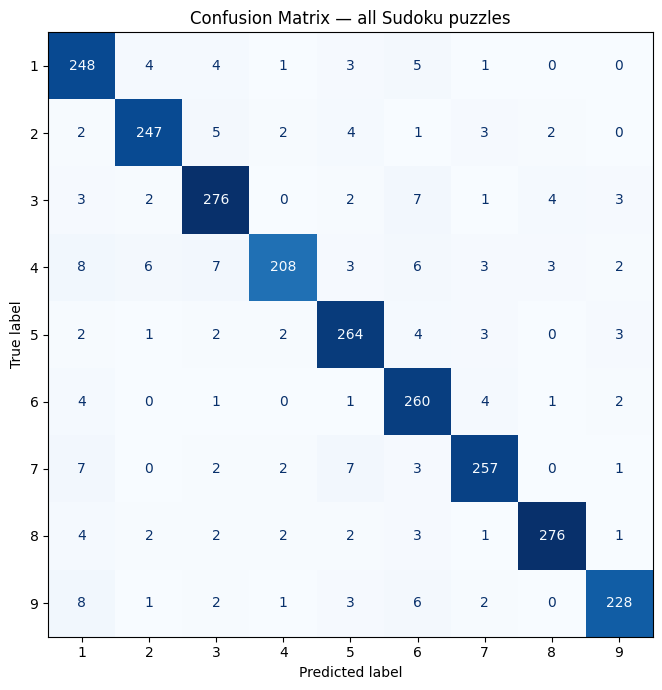

In [6]:
cm = confusion_matrix(all_true, all_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(1, 10)))
fig, ax = plt.subplots(figsize=(8, 7))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix — all Sudoku puzzles")
plt.tight_layout()
plt.show()

## 3. Puzzle-Level Metrics

In [7]:
accuracies    = [r["accuracy"] for r in detected]
n_perfect     = sum(r["perfect"] for r in detected)
n_solved      = sum(r["solved_correctly"] for r in detected)

print(f"Per-puzzle digit accuracy : mean={np.mean(accuracies)*100:.1f}%  "
      f"median={np.median(accuracies)*100:.1f}%  "
      f"min={np.min(accuracies)*100:.1f}%")
print(f"Perfect puzzle rate       : {n_perfect}/{len(detected)} "
      f"({n_perfect/len(detected)*100:.1f}%)")
print(f"End-to-end solve rate     : {n_solved}/{len(detected)} "
      f"({n_solved/len(detected)*100:.1f}%)")

Per-puzzle digit accuracy : mean=88.2%  median=96.9%  min=0.0%
Perfect puzzle rate       : 42/89 (47.2%)
End-to-end solve rate     : 42/89 (47.2%)


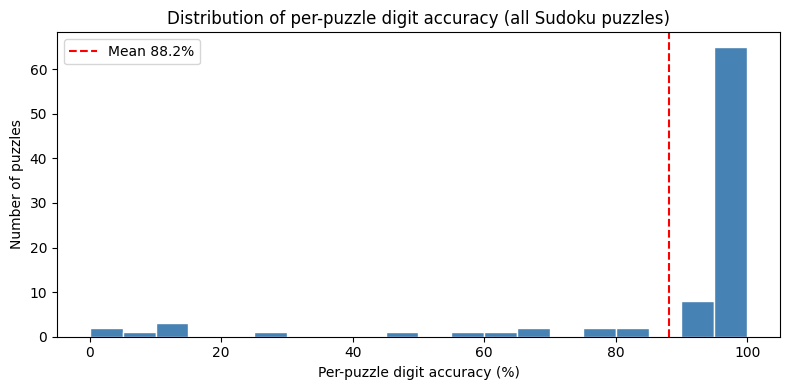

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist([a * 100 for a in accuracies], bins=20, range=(0, 100),
        color="steelblue", edgecolor="white")
ax.axvline(np.mean(accuracies) * 100, color="red", linestyle="--",
           label=f"Mean {np.mean(accuracies)*100:.1f}%")
ax.set_xlabel("Per-puzzle digit accuracy (%)")
ax.set_ylabel("Number of puzzles")
ax.set_title("Distribution of per-puzzle digit accuracy (all Sudoku puzzles)")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Summary

In [9]:
print("══════════════════════════════════════════")
print("  Evaluation Summary")
print("══════════════════════════════════════════")
print(f"  Test puzzles             : {len(puzzle_results)}")
print(f"  Grid detection rate      : {len(detected)/len(puzzle_results)*100:.1f}%")
print(f"  Total cells evaluated    : {len(all_true)}")
print(f"  Overall cell accuracy    : {overall_acc:.2f}%")
print(f"  Perfect puzzle rate      : {n_perfect/len(detected)*100:.1f}%")
print(f"  End-to-end solve rate    : {n_solved/len(detected)*100:.1f}%")
print("══════════════════════════════════════════")

══════════════════════════════════════════
  Evaluation Summary
══════════════════════════════════════════
  Test puzzles             : 203
  Grid detection rate      : 43.8%
  Total cells evaluated    : 2453
  Overall cell accuracy    : 92.30%
  Perfect puzzle rate      : 47.2%
  End-to-end solve rate    : 47.2%
══════════════════════════════════════════
